---
format: 
    html:
        embed-resources: true
        toc: true
---


# Homework-1: Regression Fundamentals 

*Author:* J. Hickman

* In this homework, we will work through a parametric statistical learning problem from start to finish from scratch.
* Much of this can be done more easily with Sk-Learn, Statsmodels, or other libraries. However, the assignment is meant to be educational.
* We want you to understand what is happening "under the hood", and understand the "training" process at a fundamental level.
* This is not just an academic exercise, this is very similar to a typical deep-learning work-flow (e.g in Keras or PyTorch)
* If you apply for deep learning jobs, you will be expected to be very familiar with all the components of this workflow. 

**Instructions** 

* Read and work through all tutorial content and do all exercises below
  
**Submission:**

* You need to upload ONE document to Canvas when you are done
  * (1) A PDF (or HTML) of the completed form of this notebook 
* The final uploaded version should NOT have any code-errors present 
* All outputs must be visible in the uploaded version, including code-cell outputs, images, graphs, etc

# Part-1: Analytical assignment

* The following is some analytical "pen and paper" work to get started.   
* If you completed assignment in a previous class, then it is fine to recycle your solution from there. Just make sure you understand it entirely.

## Relevant mathematics review  

* Work through the following math problems relevant to optimization (show your work and all steps)

* You can do this either by (1) doing the math inside `.ipynb` using LaTex (recommended) OR (2) doing it with pen and paper (or ipad), taking photographs, and embedding the solutions into the .ipynb as images, before you upload.

![](images/2023-01-22-22-45-35.png)

### Problem 1: Gradient of a 3D Plane

$$
f(x,y) = ax + by + c.
$$

The gradient vector =

$$
\nabla f(x,y)
=
\left(
\frac{\partial f}{\partial x},
\frac{\partial f}{\partial y}
\right).
$$

Derivatives:

$$
\frac{\partial f}{\partial x} = a,
\qquad
\frac{\partial f}{\partial y} = b.
$$

Therefore, the gradient vector is

$$
\nabla f(x,y) = (a, b).
$$


### Problem 2: Gradient of a Hyperplane

$$
f(x_1, x_2, \ldots, x_N)
=
\sum_{i=1}^{N} a_i x_i + d
=
a_1 x_1 + a_2 x_2 + \cdots + a_N x_N + d.
$$

The gradient vector =
$$
\nabla f(x_1, \ldots, x_N)
=
\left(
\frac{\partial f}{\partial x_1},
\frac{\partial f}{\partial x_2},
\ldots,
\frac{\partial f}{\partial x_N}
\right).
$$

Derivative:
$$
\frac{\partial f}{\partial x_i} = a_i,
\qquad i = 1, 2, \ldots, N.
$$

Gradient vector is
$$
{
\nabla f(x_1, \ldots, x_N)
=
(a_1, a_2, \ldots, a_N)
}
$$


### Problem 3: Partial Derivatives of a Paraboloid

$$
f(x,y) = A(x - x_0)^2 + B(y - y_0)^2 + C.
$$


Derivative with respect to x

$$
\frac{\partial f}{\partial x}
=
A \cdot 2(x - x_0)
=
2A(x - x_0).
$$


Derivative with respect to y

$$
\frac{\partial f}{\partial y}
=
B \cdot 2(y - y_0)
=
2B(y - y_0).
$$



### Problem 4: Matrix and Vector Operations

$$
x^T =
\begin{pmatrix}
3 & 1 & 4
\end{pmatrix},
\qquad \text{shape } (1 \times 3)
$$

$$
y^T =
\begin{pmatrix}
2 \\ 5 \\ 1
\end{pmatrix},
\qquad \text{shape } (3 \times 1)
$$


$$
B^T =
\begin{pmatrix}
3 & 5 & 1 \\
5 & 2 & 4
\end{pmatrix},
\qquad \text{shape } (2 \times 3)
$$


$$
x \cdot x = 3^2 + 1^2 + 4^2 = 26,
\qquad \text{scalar}
$$


$$
x \cdot y^T =
3(2) + 1(5) + 4(1) = 15,
\qquad \text{scalar}
$$


$$
x × y: Not\ defined
$$


$$
y × x: Not\ defined
$$


$$
A × x =
\begin{pmatrix}
4 & 5 & 2 \\
3 & 1 & 5 \\
6 & 4 & 3
\end{pmatrix}
\begin{pmatrix}
3 \\ 1 \\ 4
\end{pmatrix}
=
\begin{pmatrix}
25 \\ 26 \\ 34
\end{pmatrix},
\qquad \text{shape } (3 \times 1)
$$


$$
A × B =
\begin{pmatrix}
39 & 38 \\
23 & 41 \\
47 & 50
\end{pmatrix},
\qquad \text{shape } (3 \times 2)
$$


$$
B.\text{reshape}(1,6)
=
\begin{pmatrix}
3 & 5 & 5 & 2 & 1 & 4
\end{pmatrix},
\qquad \text{shape } (1 \times 6)
$$


## Univariate Least square derivation

![](images/2023-01-23-09-42-26.png)


$$
L(m, b) = \sum_{i=1}^{N} (y_i - (mx_i + b))^2
$$

Partial derivative with respect to m:

$$
\frac{\partial L}{\partial m} = \sum_{i=1}^{N} -2 x_i (y_i - (mx_i + b))
$$

Partial derivative with respect to b:

$$
\frac{\partial L}{\partial b} = \sum_{i=1}^{N} -2 (y_i - (mx_i + b))
$$

Derivatives to zero

$$
\sum_{i=1}^{N} x_i (y_i - (mx_i + b)) = 0
$$

$$
\sum_{i=1}^{N} (y_i - (mx_i + b)) = 0
$$

Solve for m and b

$$
b = \bar{y} - m \bar{x}, \quad \text{where } \bar{x} = \frac{1}{N}\sum x_i, \quad \bar{y} = \frac{1}{N}\sum y_i
$$

Plug b into the first equation to solve for m:

Optimal m
$$
m = \frac{\sum_{i=1}^{N} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{N} (x_i - \bar{x})^2} = \frac{\text{cov}(X,Y)}{\text{var}(X)}
$$

Optimal b
$$
b = \bar{y} - m \bar{x}
$$


# Part-2: linear vector regression (toy data)

**Overview** 

* In the previous lab, we confined ourself to the case of "scalar" regression. 
* Meaning that the modeling function received a vector as input $\mathbf x$, but only output one number (i.e a scalar).
   $$ y=M(\mathbf x | \mathbf w)$$
* Where $\mathbf w$ are the model parameters
* In this assignment we generalize the lab from last week to the case of general multi-variable vector regression. 
  $$ \mathbf y=M(\mathbf x | \mathbf w)$$
* Meaning that the model takes a vector and returns a vector.
* Your solution should be fully general
  * This means it should work for an arbitrary input matrix
  * And should be able to fit a model with an arbitrary number of fitting parameters


## Import packages 

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from   scipy.optimize import minimize
import pandas as pd
import seaborn as sns

## Data generating function

* For simplicity and clarity, we will use artificial data, that way we know the ground truth data generating function.
  
* **Ground truth**
$$y_0(\mathbf x)=1.1+3.4x_0+1.2x_1-5.6x_2$$
$$y_1(\mathbf x)=-3+2.4x_0-5.2x_1+7.6x_2$$

* We will also inject some noise into the data, to make it more realistic.

* This can be written in a vectorized matrix form as

$$ \mathbf y\mathbf(x)=\mathbf b+\mathbf w \mathbf x$$

* Since we already know the ground truth, we should see that our predicted parameters are close to the ground truth parameters
  
*  So if everything goes well, our model should predict numbers close to the following (depending on the size of the noise).

$$ \mathbf w =\begin{pmatrix}
3.4 & 1.2 & -5.6\\
2.4 & -5.2 & 7.6\\
\end{pmatrix} \,\,\,\,\,\, \mathbf b =\begin{pmatrix}
1.1  \\
-3.0  \\
\end{pmatrix}
$$

* This is a low dimensional case, however, the formalism is general, and can be extended easily to an arbitrary dimension. 


## Generate data

Let's apply the data generating function discussed above to create some toy data.

In [ ]:
N=500

# WITH NOISE
noise_magnitude=0.0
noise=noise_magnitude*np.random.normal(0,1,(N,2));

# NO NOISE

#DEFINE A RANDOM INPUT MATRIX (X) WITH THREE FEATURES
x=np.random.normal(5,2,(N,3));
x_train=x

# GENERATE DATA WITH DATA GENERATING FUNCTION
y0=1.1+3.4*x[:,0]+1.2*x[:,1]-5.6*x[:,2]+noise[:,0];
y0=y0.reshape(N,1)
y1=-3.0+2.4*x[:,0]-5.2*x[:,1]+7.6*x[:,2]+noise[:,1]
y1=y1.reshape(N,1)
# print(y0.shape,y1.shape)

# COMBINE INTO MATRIX
y=np.concatenate((y0,y1),axis=1);

# PRINT SHAPES
print("noise :",noise.shape)
print("x :",x.shape)
print("y :",y.shape)


noise : (500, 2)
x : (500, 3)
y : (500, 2)


**IMPORTANT** 

In this case we **won't** normalize the data, even though we typically would.

The reason for this is;

  * (1) The data is already on a relatively uniform scale (~100 to 100) and should be easy to fit.

  * (2) We want to relate our regression results to the expected parameterization of the data generating function. However, fitting to normalized data  would result in a parameter prediction for the normalize data rather than the original data

## Visualize the data 

Before moving on, let's take a quick look at the data

**What can we tell from this plot? Does it match what we would expect for this generating function** 

(500, 5)


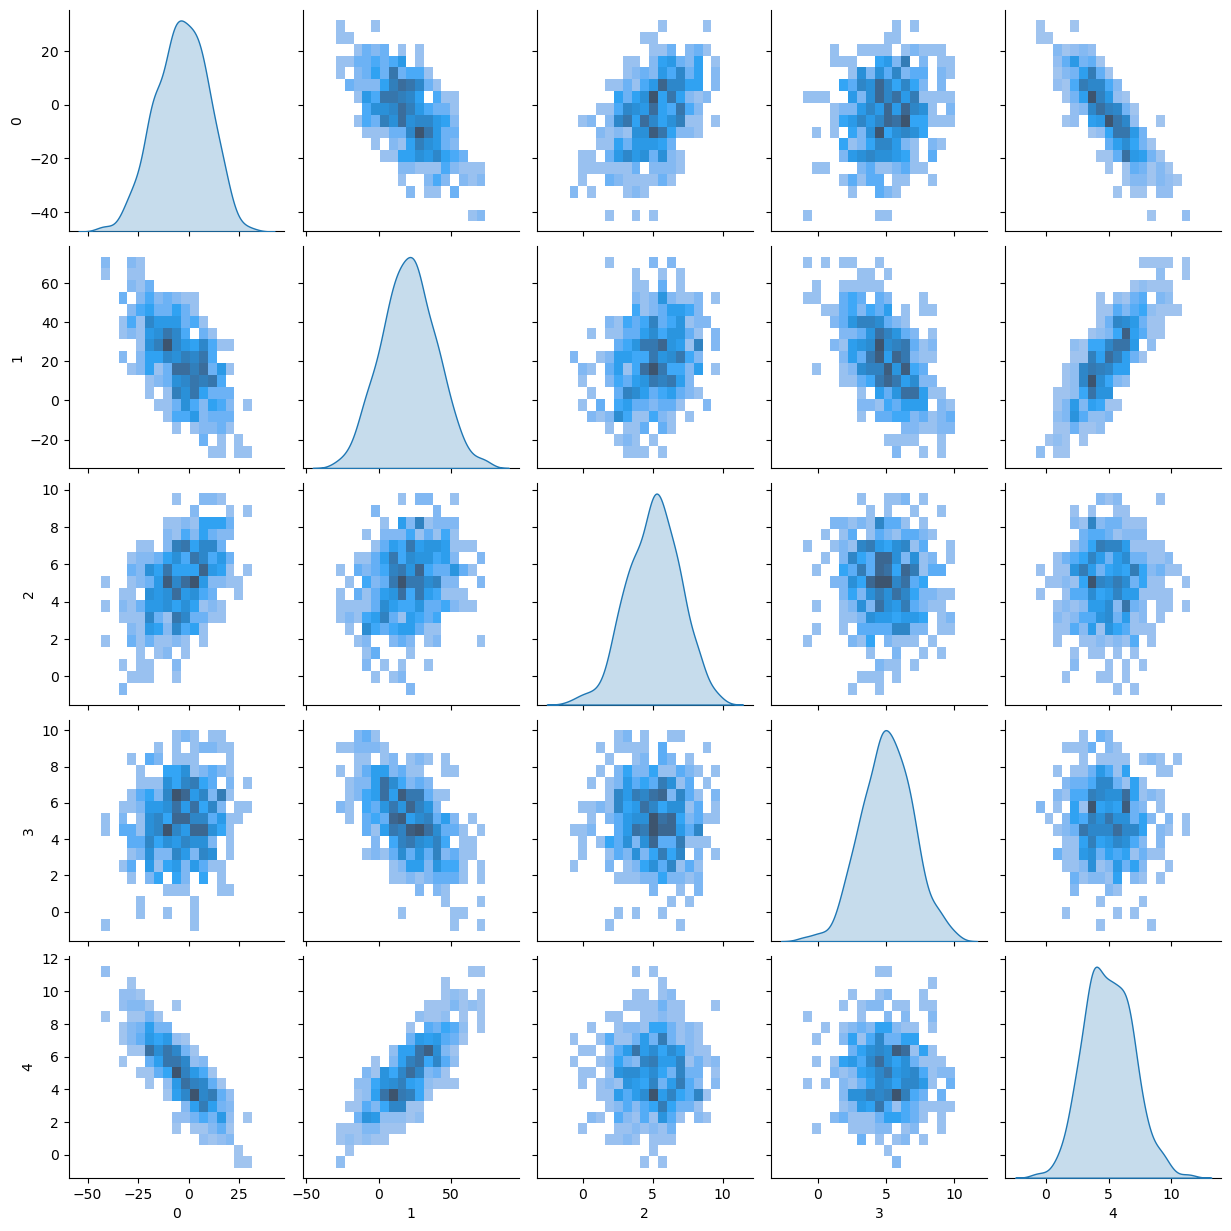

In [ ]:
tmp=np.concatenate((y,x),axis=1); print(tmp.shape)
df=pd.DataFrame(tmp)
sns.pairplot(df, diag_kind='kde', kind="hist")
plt.show()

## Sk-learn: Sanity check

* As with many models, we can do all our linear vector regression with a few lines of SkLearn code
  
* However, the point of the assignment is to understand the process, and what is happening "under the hood"

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(x, y)
reg.score(x, y)

print(reg.coef_)
print(reg.intercept_)

[[ 3.4  1.2 -5.6]
 [ 2.4 -5.2  7.6]]
[ 1.1 -3. ]


If everything worked, this should match the values of our ground truth parametrization

Remember, typically we will not know the ground truth parametrization

$$ \mathbf w =\begin{pmatrix}
3.4 & 1.2 & -5.6\\
2.4 & -5.2 & 7.6\\
\end{pmatrix} \,\,\,\,\,\, \mathbf b =\begin{pmatrix}
1.1  \\
-3.0  \\
\end{pmatrix}
$$

## Numerical training

In this case we will train the model numerically, similar to what we've done in the past.

### Define our model 

This case our model $\mathbf m$ is multi-variable linear vector regression.  

For a single input feature vector $\mathbf x^T=(x_0,x_1,x_2)$ the model is 

$$\mathbf y_{pred}=\begin{pmatrix} 
y_{0} \\ y_{1} \end{pmatrix}_{pred}=\mathbf m(\mathbf x | \mathbf w,\mathbf b)=\mathbf b+\mathbf w \mathbf x =  
\begin{pmatrix} b_{0} \\ b_{1}  
\end{pmatrix} + 
\begin{pmatrix}
w_{00} & w_{01} & w_{02}   \\
w_{10} & w_{11} & w_{12}  \\
\end{pmatrix} 
\begin{pmatrix} 
x_{0} \\ x_{1} \\ x_{2} 
\end{pmatrix}$$

Which, by design has the same form as the ground truth data generating function discussed above

It is common to introduce a constant feature, column of ones, so that the bias term $b$ can be absorbed into the $w$ matrix.

$$\mathbf x  \rightarrow \tilde{\mathbf x} =\begin{pmatrix}
1 \\ x_{0} \\ x_{1} \\ x_{2} \\
\end{pmatrix}
$$

In which case the model can be rewritten in a mathematically identical form

$$\mathbf y_{pred}=\mathbf m(\tilde{\mathbf x}| \tilde{\mathbf w})= \tilde{\mathbf w} \tilde{\mathbf x}=\begin{pmatrix}
b_{0} & w_{00} & w_{01} & w_{02} \\
b_{1} & w_{10} & w_{11} & w_{12} \\
\end{pmatrix}\begin{pmatrix} 1\\ x_0 \\ x_1 \\ x_2 \end{pmatrix}$$

Where the multiplication is matrix multiplication. 

Which obeys the shape requirements $[2 \times 4] [4 \times 1] \rightarrow [2 \times 1]$ 



## Aside: Connection to neural networks

Linear vector regression is the simplest form of an artificial neural network, as demonstrated by the following image.

![](images/2023-01-28-18-32-33.png){width=700}

In the jargon of deep learning, we would say that this is a shallow dense feed forward fully connected neural network, with no hidden layers, a three node input layer, a two node output layer, and linear activation on the output later

This concept can easily be generalized to much higher dimensions, as well as non-linear functions.

More on this later in the course.


## Batch implementation

The previous formula was for a single data-point $\mathbf x^T=(x_0,x_1,x_2)$.

The formula can also be rewritten so that it can be applied to the entire data set all at once.

Consider the following matrix of feature inputs

$$\tilde{\mathbf X} =\begin{pmatrix}
1 & x_{00} & x_{01} & x_{02} \\
1 & x_{10} & x_{11} & x_{12} \\
\vdots  & \vdots &\vdots \\
1 & x_{N0} & x_{N1} & x_{N2} \\
\end{pmatrix}$$

Model can be applied to the entire matrix as

$$\begin{pmatrix} 
y_{00} & y_{01} \dots & y_{0N} \\
y_{10} & y_{11} \dots & y_{1N}\\
\end{pmatrix}_{pred}= \tilde{\mathbf w} \tilde{\mathbf X}^T=\begin{pmatrix}
b_{0} & w_{00} & w_{01} & w_{02} \\
b_{1} & w_{10} & w_{11} & w_{12} \\
\end{pmatrix}
\begin{pmatrix}
1      & 1 &  \dots  & 1\\
x_{00} & x_{10} &\dots  & x_{N0}\\
x_{01} & x_{11} &\dots & x_{N1} \\
x_{02} & x_{12} &\dots & x_{N2} \\
\end{pmatrix}$$

Where the multiplication is matrix multiplication. 

Which obeys the shape requirements $[2 \times 4] [4 \times N] \rightarrow [2 \times N]$ 

**In Summary:** We can evaluate the entire model, for all inputs at once, with the formula above.

## Prepare the data

In [ ]:
# INSERT CODE HERE TO ADD A COLUMN OF ONES TO THE INPUT FEATURE MATRIX

**Split the data**

As usual let's split our data into training and validation.

Note: If you have already completed homework-1, then you can recycle some of that code here.

In [ ]:
#INSERT CODE TO PARTITION THE DATA INTO AN 80-20 SPLIT

In [ ]:
# RE-PRINT THE SHAPES
print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)

(400, 4) (400, 2)
(100, 4) (100, 2)


## Set up the model

In [ ]:
# INSERT CODE TO CONSTRUCT AN INITIAL GUESS FOR THE MATRIX
# If you're using sci-py minimizer below, then this should be a long vector of the unwrapped matrix
# Think carefully about the correct shape, this can be inferred from the shapes of x_train and y_train

In [ ]:
# RUN THE FOLLOWING CODE
print("INITIAL GUESS: w_0 =\n",w0)
print("SHAPE:",w0.shape)

In [ ]:
# INSERT CODE TO EVALUATE THE BATCH IMPLEMENTATION OF THE VECTOR REGRESSION MODEL
# DISCUSSED ABOVE (don't over-think it, it is a two-line model)
# If you're input of the parameters is a vector, you will need to reshape it into a matrix

In [ ]:
# INSERT CODE FOR THE LOSS FUNCTION (USE RMSE)
# NOTE YOU MAY NEED TO RESHAPE y_pred SO THAT IT IS THE SAME SHAPE AS y_train

## Train the model numerically

In [ ]:
# INSERT CODE TO FIT THE MODEL USING NUMERIC OPTIMIZATION
#   YOU CAN USE THE SCI-PY MINIMIZER OR THE MINIMIZER YOU CODED FROM HW-1)

NUMERICAL PARAMETER PREDICTION:   
= [[ 1.10000057  3.39999999  1.19999995 -5.60000008]
 [-2.99999926  2.39999996 -5.20000007  7.59999997]]


If everything worked, this should match the values of our ground truth parametrization

Remember, typically we will not know the ground truth parametrization

$$ \mathbf w =\begin{pmatrix}
3.4 & 1.2 & -5.6\\
2.4 & -5.2 & 7.6\\
\end{pmatrix} \,\,\,\,\,\, \mathbf b =\begin{pmatrix}
1.1  \\
-3.0  \\
\end{pmatrix}
$$

In [ ]:
# INSERT CODE TO PRINT THE RMSE FOR THE VALIDATION AND TRAINING SET

TRAINING LOSS (RMSE) :  1.7492130002159827e-07
VALIDATION LOSS (RMSE) :  1.8530625528656306e-07


## Analytic "training"

Here we will train the model using the analytical solution, derived with pen and paper, instead of numerical optimization.


* In practice, we don't actually have to use numerical optimization to solve the vector linear regression problem
* Just as with scalar regression, we can use the formula we derived with "pen and paper" 
* Notice that the columns of Y are independent, since the various columns don't explicitly depend on each other.
* Therefore, the vector-regression is just repeated scalar regression (i.e. what we did in the homework)
* So you can simply apply the standard scalar regression formulae to each $y_i$ one at a time.
* Insert code below to write a for loop to iterate over the columns of $\mathbf y$ 
* For each column apply the scalar linear regression formula that you derived in HW-1
 $$\mathbf w = (\mathbf x^T \mathbf x)^{-1} \mathbf x^T y$$
* Recall that to use this formula you need to add a "constant feature", a column of ones, to the x_train matrix to account for the bias parameter 
  * `x_train[0,:]=[A,B,C]` $\rightarrow$ `x_train[0,:]=[0,A,B,C]`
  * `x_train[1,:]=[A,B,C]` $\rightarrow$ `x_train[1,:]=[0,A,B,C]`
  *  ... etc
*  Which we already did above
*  You also need to take the transpose `x.T`, the inverse `np.linalg.inv()`, and three matrix products `np.matmul`
*  Using the `y_train` and the modified `x_train`, your numbers should match Sk-Learn perfectly 
   *  (because this is the formula that Sk-Learn uses, NOT numerical optimization) 


In [ ]:
# INSERT CODE HERE

[ 1.1  3.4  1.2 -5.6]
[-3.   2.4 -5.2  7.6]


If everything worked, this should match the values of our ground truth parametrization

Remember, typically we will not know the ground truth parametrization

$$ \mathbf w =\begin{pmatrix}
3.4 & 1.2 & -5.6\\
2.4 & -5.2 & 7.6\\
\end{pmatrix} \,\,\,\,\,\, \mathbf b =\begin{pmatrix}
1.1  \\
-3.0  \\
\end{pmatrix}
$$

# Part-3: Coding the optimizer

## Import

In [ ]:
import  pandas  as  pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from   scipy.optimize import minimize

## Multi-variable gradient decent

* This was already done in a previous assignment, assuming you completed that assignment correctly, feel free to recycle that code here
* In a function call `minimizer`
* Generalize the single variable gradient descent algorithm to the case of multiple variables 
* In this case the parameter $w_i$ becomes a vector $\mathbf w_i$ (i.e. a numpy array)
* This is also the case for the derivative, which becomes the gradient (another numpy array)
$$\mathbf \nabla L = \left(\frac{\partial L}{\partial w_0},\frac{\partial L}{\partial w_1} \dots \frac{\partial L}{\partial w_N}\right)$$
* Each term in the gradient can be calculated by keeping all variables constant, except one, and applying the finite difference formula. 
* For example, consider just two variables, and computing $\frac{\partial L}{\partial w_0}$
  * $\mathbf w_i=(w_{i,0},w_{i,1})$
  * The perturbation for $w_0$ is $\mathbf \Delta w_0=(\Delta w,0)$ and $\mathbf \Delta w_1=(0,\Delta w)$ for $w_1$
  * the component of the gradient would be $\frac{\partial L}{\partial w_0}\approx \frac{L(\mathbf w_i+\mathbf \Delta w_0)-L(\mathbf w_i-\mathbf \Delta w_0)}{2\Delta w}$
  * where $\Delta w$ is a small number (hyper-parameter)
* Your code should be fully general and work for a $\mathbf w$ of arbitrary dimension
* **Optional:** Try extending the GD algorithm to `momentum` or `RMSprop`. 
  * These algorithms are similar to GD but are superior in several ways, and more common in deep learning.

In [71]:
# INSERT YOUR CODE HERE
def minimizer(l,wi,LR=0.001,tol=0.00001):


## Sanity check

* As a sanity check, find the minimum using SciPy of a scalar field with FOUR dependent variables. 

* i.e. find $(w_0,w_1,w_2,w_3)$ which minimize $L(w_0,w_1,w_2,w_3)$
* **Note:** There is no limit to the dimensionality, we could use the exact same procedure to minimize a scalar function of 512 variables $L(w_0,w_1, \dots, w_2,w_{511})$, it would just be slower 
  
* Use the following simple example to bench-mark your algorithm 
  

In [ ]:
# DEFINE FUNCTION
def L4(w_i):
    # (w0,w1,w2,w3) --> L TYPE OBJECTIVE FUNCTION
    return 8.343+(w_i[0]-3)**2.0+(w_i[1]-4)**2+(w_i[2]-10)**2+(w_i[3]-(-5))**2

# EXPECTED
print("EXPECTED ANSWER --> (w0,w1,w2,w3)=(3,4,10,-5)  with L((3,4,10,-5))=8.343")

# INITIAL GUESS
w_0=np.array([0.1,0.1,0.1,0.1])
print("INITIAL GUESS: w_0 =",w_0)

# RUN MINIMIZER
res = minimize(L4, w_0, method='BFGS', tol=1e-15)

# PRINT RESULT
w_opt=res.x
print("NUMERICAL SOLUTION: w_opt =",w_opt)
print(" L(w_opt) =",L4(w_opt))

EXPECTED ANSWER --> (w0,w1,w2,w3)=(3,4,10,-5)  with L((3,4,10,-5))=8.343
INITIAL GUESS: w_0 = [0.1 0.1 0.1 0.1]
NUMERICAL SOLUTION: w_opt = [ 2.99999999  3.99999998 10.         -5.        ]
 L(w_opt) = 8.343


## Test your function

* Apply your minimizer to the L4 objective function, your solutions should match those found with SciPy

In [73]:
# INSERT CODE TO TEST YOUR MINIMIZER FUNCTION AND PRINT THE RESULT

INITIAL GUESS: w_0 = [0.1 0.1 0.1 0.1]
STOPPING CRITERION MET (STOPPING TRAINING)
NUMERICAL SOLUTION: w_opt = [ 2.99734228  3.99642582  9.99092709 -4.99532608]
 L(w_opt) = 8.343124001389784


# Part-4: Regression on MPG dataset

## Download the data

* The Auto MPG dataset
* The dataset is available from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).
* First download and import the dataset using pandas:


In [74]:

url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

df = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)


## Numerically explore the data 

In [ ]:
#GENERAL STUFF THAT IS
print("----------------------")
print("GENERAL:")
print("----------------------")
print("number of rows:", len(df.index))
print("number of col:",  len(df.columns))
print("keys:",  df.keys(),type(df.keys()))
print("info",df.info() )
print("head", df.head())
print("TYPES", df.dtypes)

print("----------------------")
print("BASIC STATISTICS:")
print("----------------------")
print(df.describe())

print("----------------------")
print("CORRELATION MATRIX:")
print("----------------------")
print(df.corr())

----------------------
GENERAL:
----------------------
number of rows: 398
number of col: 8
keys: Index(['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model Year', 'Origin'],
      dtype='object') <class 'pandas.core.indexes.base.Index'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB
info None
head     MPG  Cylinders  Displacement  Horsepower  Weight  Acceleration  \
0  18.0          8         307.0       130.0  3504.0  

## Visually explore the data
* Reproduce the following plots with seaborn

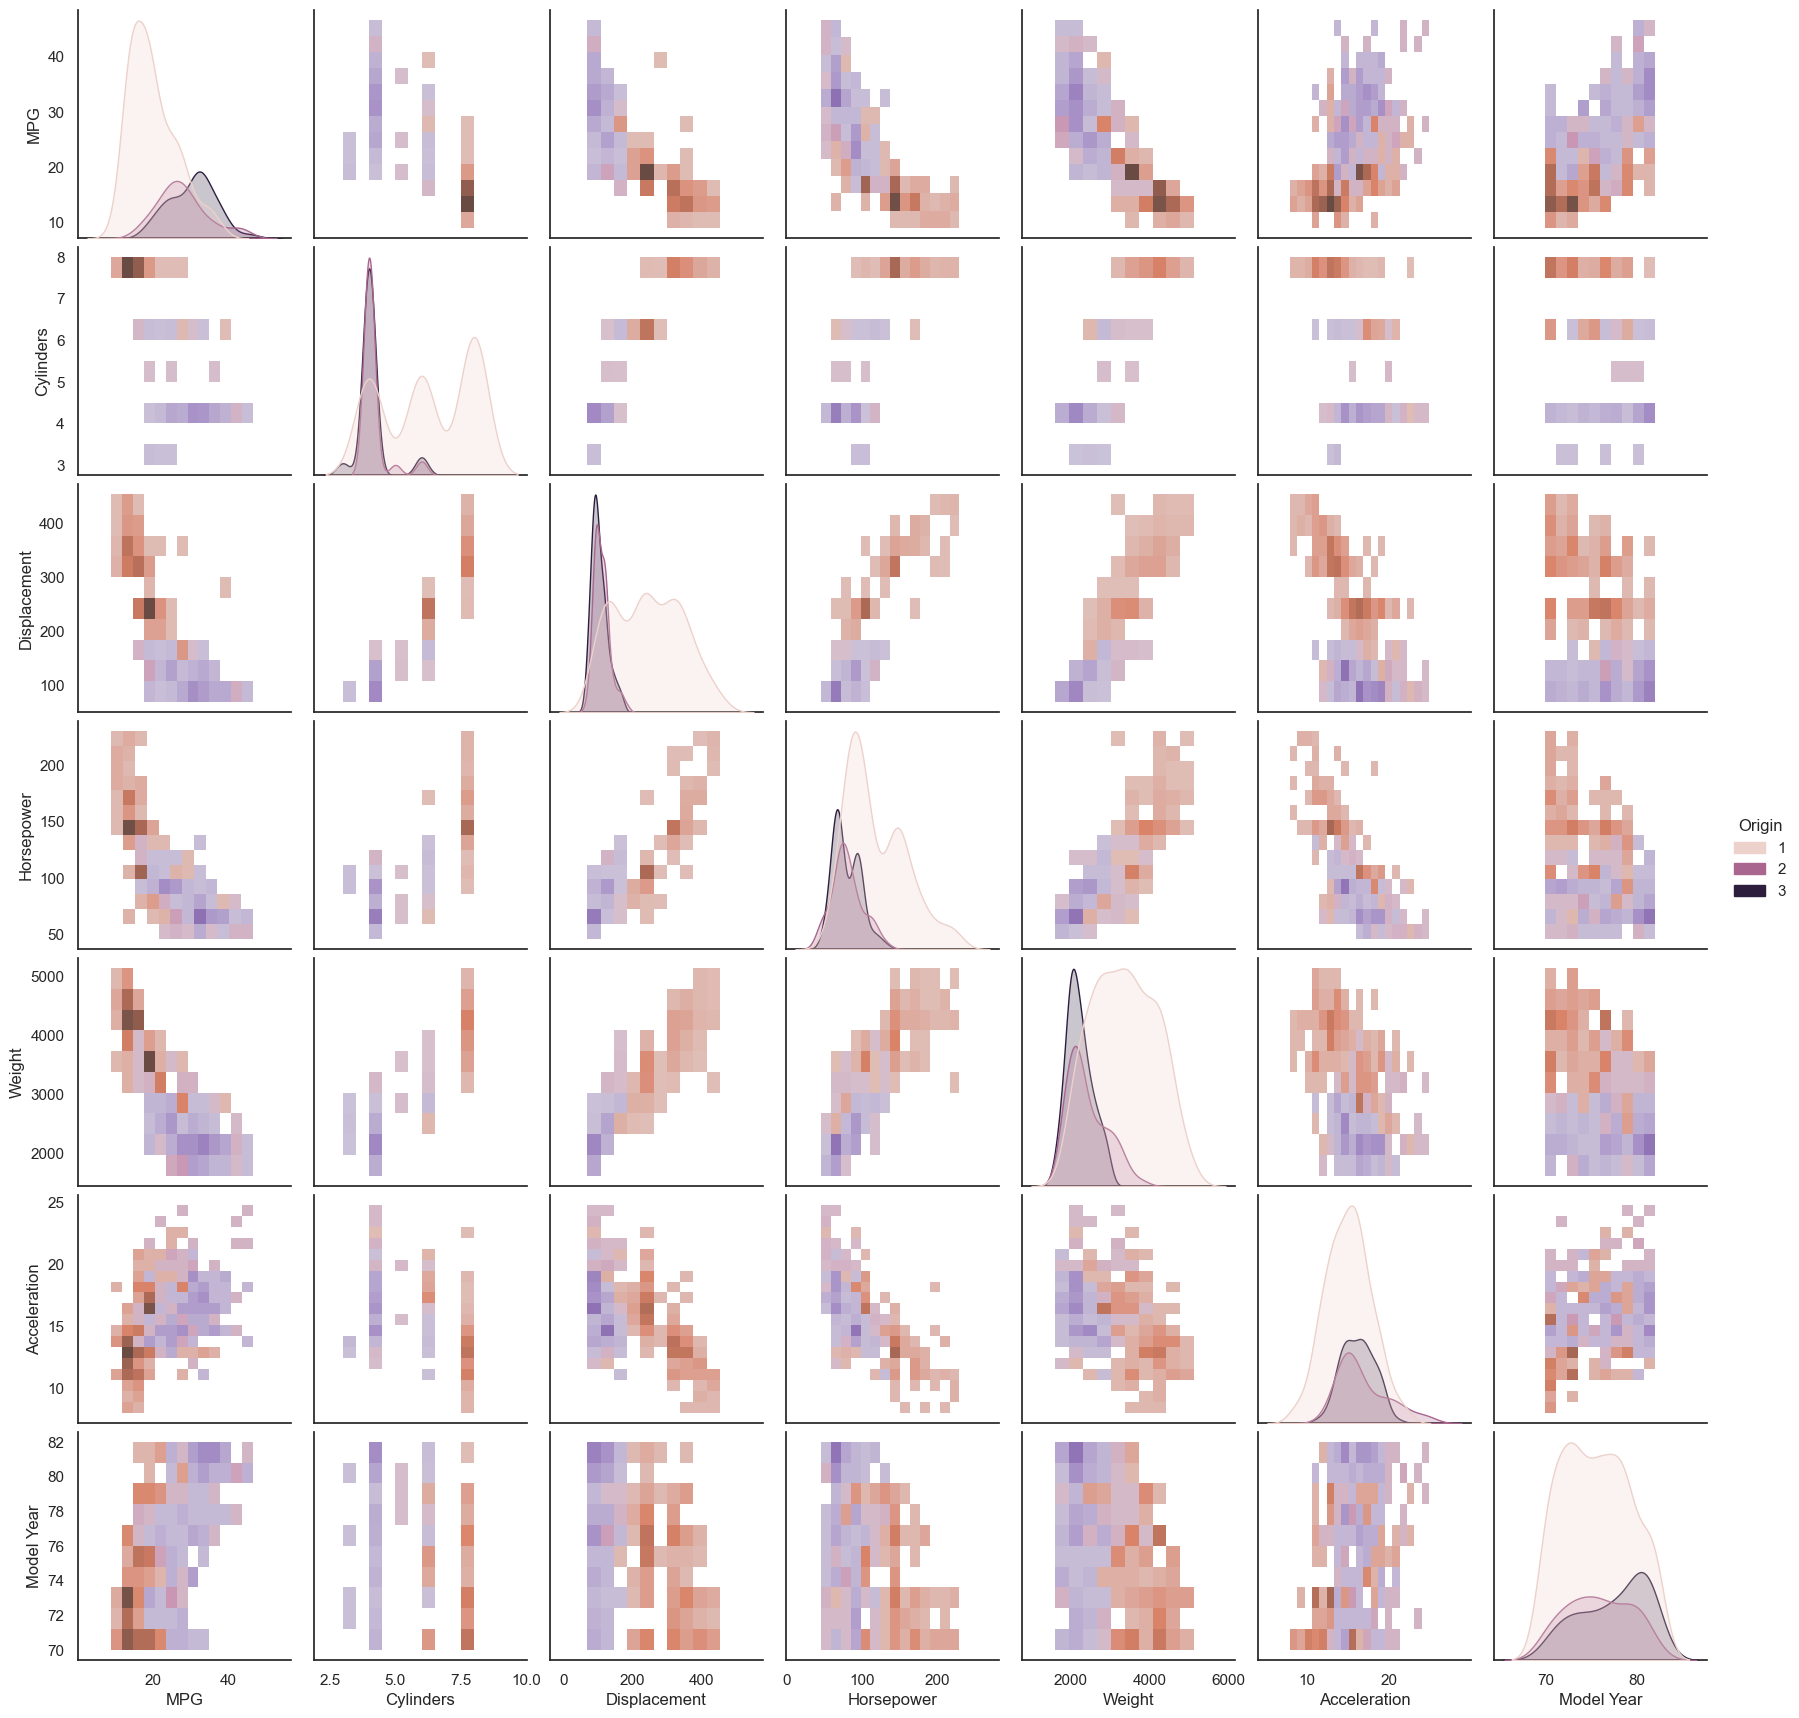

In [76]:
HUE='Origin'

# INSERT CODE TO GENERATE THE FOLLOWING PAIR PLOT


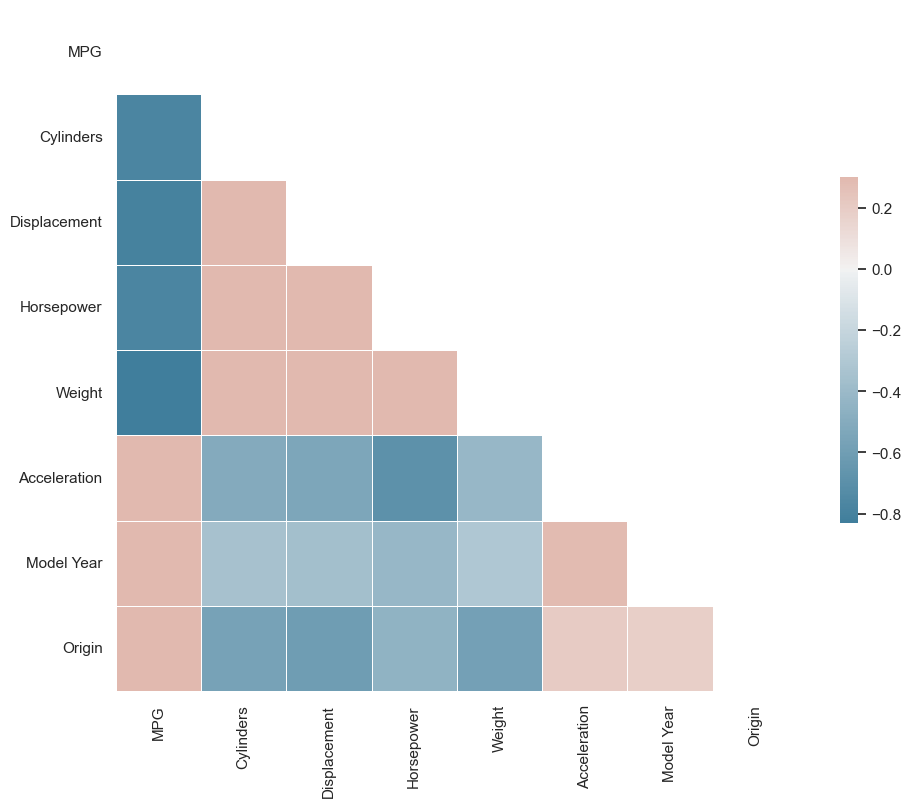

In [77]:
#INSERT CODE TO THE FOLLOWING CORRELOGRAM


## Short answer 
* Assuming MPG is your target regression variable $y$
* Do some manual feature selection (i.e. keep features that are correlated with the target and remove highly correlated features) 
* Which are the features $x$ would be best to keep, and which can be thrown away?
* Justify your answer for each feature

INSERT YOUR ANSWER HERE


## Set up the data for regression

* Regardless of what you put in the short answer sections 
* Please use the following columns of the data-frame `[1,2,3,4,5]` as the input x features, and column `0` for y.
* This is to ensure consistency across the various student's solutions 
* Extract these portions of the data-frame and store them as numpy arrays


In [ ]:
# INSERT CODE TO EXTRACT THE RELEVANT SUB-MATRICES
# x_col=[1,2,3,4,5];
# y_col=[0];

In [79]:
# YOUR DATA SHOULD BE IN NUMPY ARRAYS WITH THE FOLLOWING SHAPE
print(y.shape)
print(x.shape)

(398, 1)
(398, 5)


In [80]:
#INSERT CODE TO REMOVE ANY NAN IF PRESENT

In [81]:
# RE-PRINT THE SHAPE
print(y.shape)
print(x.shape)

(392, 1)
(392, 5)


In [82]:
# INSERT CODE TO STORE THE MEAN AND STD FOR LATER NORMALIZATION

In [83]:
#INSERT CODE TO PARTITION THE DATA INTO AN 80-20 SPLIT

In [84]:
# RE-PRINT THE SHAPES
print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)


(313, 5) (313, 1)
(79, 5) (79, 1)


In [ ]:
#INSERT CODE TO NORMALIZE THE TRAINING AND VALIDATION DATA

## Model fitting

* Here we will use our optimizer from part-1 to train a multi-variable model using linear regression 
* For this model, With N features, their will be N+1 fitting parameters
* Indexing from one
    * $y_{pred}=w_{N+1}+w_1 x_1+w_2 x_2+ \dots + w_{N} x_{N}$
    * $w_{N+1}$ being the bias (intercept)
* Indexing from zero 
    * $y_{pred}=w_N+w_0 x_0+w_1 x_1+ \dots + w_{N-1} x_{N-1}$
    * $w_{N}$ being the bias (intercept)
* Note that this model can be applied to `x_train` with one line of numpy code

In [86]:
# INSERT CODE TO TRAIN THE MODEL


In [87]:
# INSERT CODE FOR THE LOSS FUNCTION
# NOTE YOU MAY NEED TO RESHAPE y_pred SO THAT IT IS THE SAME SHAPE AS y_train

In [ ]:
#INSERT CODE TO FIT THE MODEL
# I FOUND THE FOLLOWING HYPER-PARAMETERS WORKED WELL (LR=0.01, tol=10**-10)
# ALTHOUGH YOURS MIGHT NEED TUNING DEPENDING ON HOW YOU CODED THE OPTIMIZER


In [89]:
# MAKE PREDICTIONS
y_train_pred=model(x_train,w_final)
y_val_pred=model(x_val,w_final)


## Visualize the results

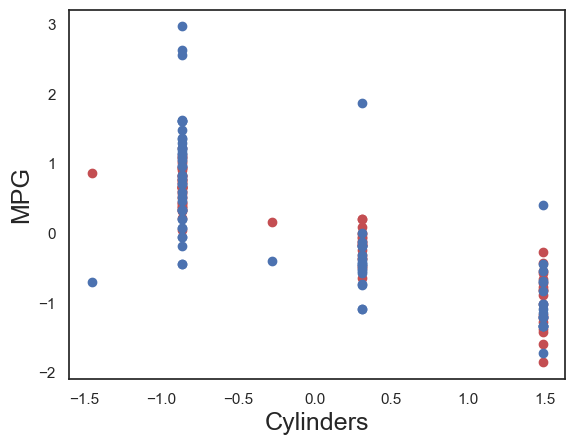

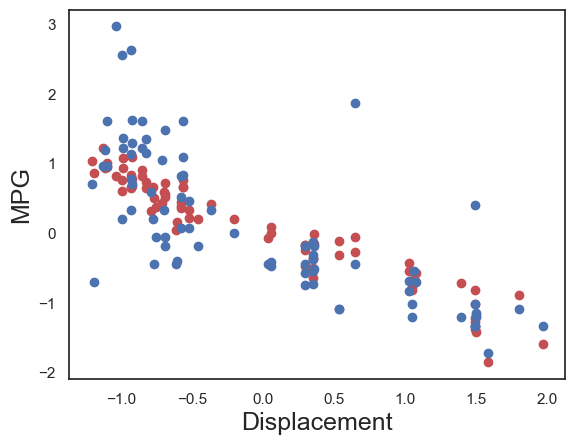

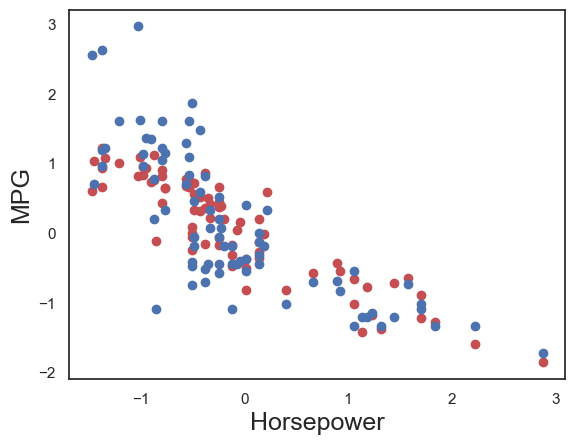

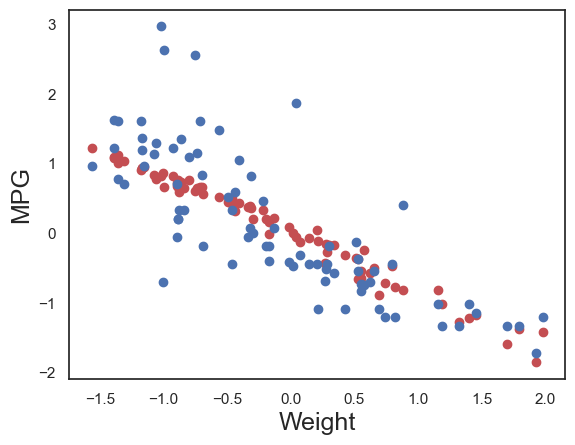

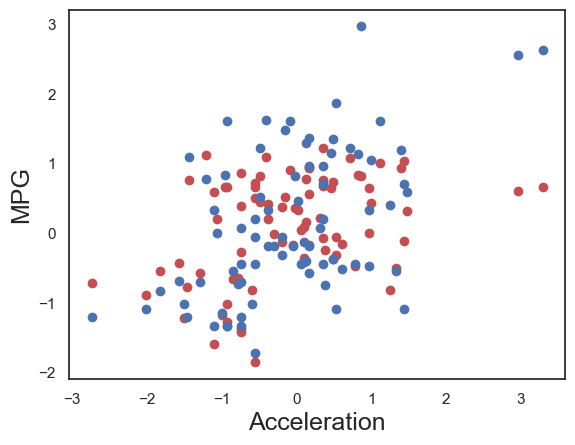

In [90]:
# INSERT CODE TO PLOT MPG VS EACH OF THE VARIOUS FEATURES  (DO WITH A LOOP)
# USE BLUE=DATA AND RED=PREDICTION (DO ONLY FOR UNTRAINED VALIDATION SET)


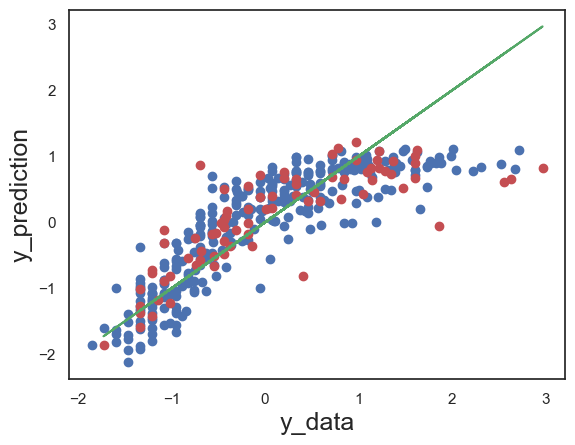

In [ ]:
## INSERT CODE FOR A PARITY PLOT (i.e. y_train vs y_train_pred AND  y_val vs y_val_pred)
# USE RED FOR VALIDATION DATA AND BLUE FOR TRAINING


## Sanity check-1

* Now lets check our parameter estimates using Sk-Learn
  
* Implement linear regression with Sk-Learn using `x_train, y_train` 
* Print estimate prediction for the  weights and bias results 
* This can be found in just a few lines. 
* **IMPORTANT**: Your parameter estimates should match those predicted by the numerical optimization process above

In [ ]:
# INSERT CODE HERE

## Sanity check-2

* Finally, let's check our parameter estimates using the multi-variable formula derived in the optional section of Part-1: $\mathbf w = (\mathbf x^T \mathbf x)^{-1} \mathbf x^T y$

*  **IMPORTANT:** Remember that these parameters from this formula are still "learned" through an optimization process, however the optimization is done with pen and paper, not numerically. 
* To use this formula you need to add a "constant feature", a columns of ones, to the x_train matrix to account for the bias parameter 
  * `x_train[0,:]=[A,B,C]` $\rightarrow$ `x_train[0,:]=[0,A,B,C]`
  * `x_train[1,:]=[A,B,C]` $\rightarrow$ `x_train[1,:]=[0,A,B,C]`
  *  ... etc
*  You also need to take the transpose `x.T`, the inverse `np.linalg.inv()`, and three matrix products `np.matmul`
*  Using the `y_train` and the modified `x_train`, your numbers should match Sk-Learn perfectly (because this is the formula that Sk-Learn uses, NOT numerical optimization) 


In [ ]:
# INSERT CODE HERE